## Understanding Perceptron Learning Algorithm

### 1. Data Loading and Exploration (5 points)
* Brief overview of the task.
* Description of the dataset used for analysis.

In [1]:
## Import necessary libraries
import pandas as pd
import numpy as np
from numpy import loadtxt

In [2]:
!pip install ucimlrepo

In [3]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
raisin = fetch_ucirepo(id=850)
df = pd.read_excel("Raisin_Dataset.xlsx") 
 

print(raisin.metadata)

# data (as pandas dataframes)
X_temp = raisin.data.features
y_temp = raisin.data.targets



# metadata
print(raisin.metadata)

# variable information
print(raisin.variables)

{'uci_id': 850, 'name': 'Raisin', 'repository_url': 'https://archive.ics.uci.edu/dataset/850/raisin', 'data_url': 'https://archive.ics.uci.edu/static/public/850/data.csv', 'abstract': 'Images of the Kecimen and Besni raisin varieties were obtained with CVS. A total of 900 raisins were used, including 450 from both varieties, and 7 morphological features were extracted.', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 900, 'num_features': 7, 'feature_types': ['Real', 'Integer'], 'demographics': [], 'target_col': ['Class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2020, 'last_updated': 'Fri Jan 05 2024', 'dataset_doi': '10.24432/C5660T', 'creators': ['İ̇lkay Çinar', 'Murat Koklu', 'Sakir Tasdemir'], 'intro_paper': {'ID': 261, 'type': 'NATIVE', 'title': 'Kuru Üzüm Tanelerinin Makine Görüşü ve Yapay Zeka Yöntemleri Kullanılarak Sınıflandırılması', 'authors': 'İ̇lkay Çinar

In [235]:
from pandas import read_csv

In [236]:
## Read the regression data and transform it into a Numpy array collection.
## (See pandas and numpy functions)

In [4]:

df["Class"] = np.where(df["Class"] == "Kecimen", 1, -1)#giving class numerical values
#for perceptron 
print(df["Class"].unique())
print(df.columns)
print(df.head())




[ 1 -1]
Index(['Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity',
       'ConvexArea', 'Extent', 'Perimeter', 'Class'],
      dtype='object')
    Area  MajorAxisLength  MinorAxisLength  Eccentricity  ConvexArea  \
0  87524       442.246011       253.291155      0.819738       90546   
1  75166       406.690687       243.032436      0.801805       78789   
2  90856       442.267048       266.328318      0.798354       93717   
3  45928       286.540559       208.760042      0.684989       47336   
4  79408       352.190770       290.827533      0.564011       81463   

     Extent  Perimeter  Class  
0  0.758651   1184.040      1  
1  0.684130   1121.786      1  
2  0.637613   1208.575      1  
3  0.699599    844.162      1  
4  0.792772   1073.251      1  


In [238]:
## Explore the dataset (e.g., size, features, target variables, summary statistics).
## Check for any missing values and handle them if necessary.

# Summary statistics
print("\nSummary statistics:\n")
print("Data Size is :",df.shape[0]*df.shape[1])
print("Features are :",X_temp.columns.tolist())
print("Target variables are :",y_temp.columns.tolist())
print("IQR is:" ,df.drop(columns=["Class"]).quantile(0.75)-df.drop(columns=["Class"]).quantile(0.25))
print(df.describe()) #shows mean,stand variation, non null values number and quantiles


# Check for missing values
print("\n Missing Columns for every feature: \n")
df.isna().sum()



Summary statistics:

Data Size is : 7200
Features are : ['Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity', 'ConvexArea', 'Extent', 'Perimeter']
Target variables are : ['Class']
IQR is: Area               45680.250000
MajorAxisLength      148.744116
MinorAxisLength       60.777448
Eccentricity           0.100805
ConvexArea         46862.500000
Extent                 0.064122
Perimeter            341.979000
dtype: float64
                Area  MajorAxisLength  MinorAxisLength  Eccentricity  \
count     900.000000       900.000000       900.000000    900.000000   
mean    87804.127778       430.929950       254.488133      0.781542   
std     39002.111390       116.035121        49.988902      0.090318   
min     25387.000000       225.629541       143.710872      0.348730   
25%     59348.000000       345.442898       219.111126      0.741766   
50%     78902.000000       407.803951       247.848409      0.798846   
75%    105028.250000       494.187014       279.888575     

Area               0
MajorAxisLength    0
MinorAxisLength    0
Eccentricity       0
ConvexArea         0
Extent             0
Perimeter          0
Class              0
dtype: int64

In [18]:
# Convert the DataFrame to a Numpy array

In [5]:
from numpy import array
X = df.drop(columns=["Class"]).to_numpy(dtype=float)
y = df["Class"].to_numpy(dtype=float)

### 2. Data Preprocessing (5 points)
Explain the preprocessing steps taken and their rationale.

#### Feature Scaling Techniques:
Feature scaling is important for many machine learning algorithms, especially those based on distance metrics (e.g., k-nearest neighbors, support vector machines) and gradient descent optimization (e.g., linear regression, logistic regression).

Some common feature scaling techniques include:

1. **Standardization (Z-score normalization):** It scales the features to have a mean of 0 and a standard deviation of 1.
2. **Min-Max Scaling:** It scales the features to a fixed range, typically between 0 and 1.
3. **Robust Scaling:** It scales the features based on percentiles, making it robust to outliers.

You can use these scaled features for training your machine learning models.

Remember, the choice of feature selection and feature scaling techniques can significantly impact the performance of your models. It's essential to experiment and choose the techniques that work best for your specific dataset and machine learning tasks.

In [231]:
## Analyze the dataset and decide whether scaling is needed.
## Explain your choices in a brief comment.


#m, s = X_train.mean(axis=0), X_train.std(axis=0)
#s[s==0] = 1
#X_train = (X_train - m) / s
#X_test = (X_test - m) / s
#print(X_train)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_array_scaled = scaler.fit_transform(X)#standard scaling on data 


In [232]:
## 1)EQUAL INFLUENCE
'''In our features e.g "area" can be up to 100.000 while eccentrity is can be maximum 0.8 , in this situation
area effects the perceptron algorithm more because its gradient steps are larger.But if we use standardization
(mean=0,std=1) perceptron treats each feature equally and all of them have comparable variance.
'''
##2)FASTER CONVERGENCE
'''Perceptron uses iterative updates for optimal weights,with standardization; updates move more smoothly in all feature directions.'''
##3)SYMETRIC AND CENTERED DATA HELPS DECISION BOUNDARY
'''Since standardized data features centered around 0 (mean=0) the decision boundary learned by the perceptron 
also tends to be more balanced around origin,helps convergence overall this provides balanced feature influence '''

'Since standardized data features centered around 0 (mean=0) the decision boundary learned by the perceptron \nalso tends to be more balanced around origin,helps convergence overall this provides balanced feature influence '

#### Training and Validation Split
1. Explain why it’s important to use the validation set to evaluate your model instead
of relying solely on the training data.
2. Discuss how evaluating the model on unseen
data helps in assessing its generalization capability.

In [ ]:
'''If we use all data just for training then, when our model came across new data, it cannot perform well so
we need to provide unseen validation data and make sure model makes accurate predictions even on the
data that not seen before. If model's generalization is not good enough it just make perfect predictions
on training data,even for the noises, but when it evaulates on unseen data, the predictions becomes very bad
which is the case of overfitting. In short evaulating unseen data helps us to realize if there is 
overfitting condition and make sure the us the generelalization of model is enough'''

In [233]:
# Split the dataset into training and testing sets (80% train, 20% test)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_array_scaled, y, train_size=0.8, test_size=0.2,random_state=42, stratify=y)

# Print the shapes of the resulting sets
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of Y_train:", y_train.shape)
print("Shape of Y_test:", y_test.shape)

Shape of X_train: (720, 7)
Shape of X_test: (180, 7)
Shape of Y_train: (720,)
Shape of Y_test: (180,)


### 3. Implementing Perceptron for Binary Classification (20 points)

Explain the reason behind the application of perceptron learning algorithm on this type of data. If the dataset had two classes but was not linearly separable, how would the perceptron's performance change? Briefly explain.

In [ ]:
'''The Perceptron Learning Algorithm is suitable for this dataset because it is a binary classification
problem and all features are continous and numerical. According to the assignment,
the data is linearly separable; therefore,the Perceptron algorithm will converge 
within a finite number of epochs to find a separating hyperplane that classifies the two classes 
correctly.'''

'''If the dataset were not linearly separable, the Perceptron would fail to converge, 
since no single linear boundary could perfectly separate the classes.
In such a case, the algorithm would continue updating the weights indefinitely 
or until the maximum epoch limit is reached, 
trying to reduce the classification error as much as possible. 
Consequently, its performance would degrade, 
and the final boundary would only approximate the best possible linear separation rather than perfectly classifying all samples.'''


####  Implement Percepton Learning Algorithm

 The use of basic libraries like Matlab, pandas, and numpy is allowed, but the use of ready-to-use libraries such as scikit-learn is prohibited

In [235]:
class Perceptron:
    def __init__(self, learning_rate, epochs, random_state):
        n_samples, n_features = X.shape #initial values while creating an instance
        self.lr = learning_rate
        self.epochs = epochs
        self.random_state = random_state
        self.weights = np.zeros(n_features)
        self.bias = 0.0 

    def fit(self, X, y):
        n_samples, n_features = X.shape #weight matrice defined according to shape of feature matrice
        rng = np.random.default_rng(self.random_state)
        self.weights = np.zeros(n_features)
        self.bias = 0.0

        for epoch in range(self.epochs):#Loop until find the best weights for hyperplane
            errors = 0
            for i in rng.permutation(n_samples):
                x_i, y_i = X[i], y[i]
                z = np.dot(x_i, self.weights) + self.bias
                y_pred = 1 if z >= 0 else -1
                if y_pred != y_i:#if classifications doesnt match update weight and bias as proper to perceptron rule
                    self.weights += self.lr * y_i * x_i
                    self.bias += self.lr * y_i
                    errors += 1
            if errors == 0:# if data is linearly seperable it will converge and prints statement
                print(f" Converged at epoch {epoch+1}")
                break

    def predict(self, X):
        # ensure weights exist
        if self.weights is None:
            raise ValueError("Model not fitted yet. Call 'fit' first.")
        z = X @ self.weights + self.bias #Linear output
        return np.where(z >= 0, 1, -1) #Classify it according to its sign(step function)





*Explain each parameter used in your perceptron model (for example: weights, bias, learning rate, random_state, shuffle, etc.).  
For each parameter, describe in detail its role in the model’s learning process and explain why it is important.*

##### * Make sure you have defined all the necessary parameters in your perceptron model to optimize its performance.

Discuss how the choice of learning rate and the number of epochs might affect the
training process. What happens with a very small or very large learning rate?

In [ ]:
##Weights:
'''Weight matrice in perceptron model provides us a hyperplane equation's coefficients which 
seperates our data linearly into two classes. Throughout the  perceptron algorithm we try to find the best matrice
for this binary classification task and stop when it converged'''
##Bias:
'''Our Raisin data may include noise so while calculating the best seperation hyperplane we need to consider the
noises in the data so when we took the dot product of weight matrice and input features 
than we add bias for more accurate calculation'''
##Learning_Rate:
'''While we trying to find the best weights for our hyperplane through the loop,the learning step is the equivelant 
of how much we are changing the direction of this hyperplane so its like the step that we re making in each loop
and for not escape the ideal hyperplane,we should keep the learning rate as small as we can so it doesnt pass
the ideal hyperplane for our classification task'''
##Random_State:
'''Random state just fixes the randomness (data shuffling,initialization) so perceptron produces  
reproducible results in every run'''


#### Accuracy implementation

In [236]:
def accuracy(y_pred,y_test):
 accuracy = np.mean(y_pred == y_test)
 return accuracy

#### Train the Perceptron

In [237]:
## Train the Perceptron model on the training set. You will use all features in the first classification.

In [238]:
p = Perceptron(learning_rate=0.01, epochs=5000,random_state=42)#perceptron instance
p.fit(X_train, y_train)

#### Prediction on Training Data

In [239]:
# Predicting on the training data
y_pred_training=p.predict(X_train)
accuracy_train=accuracy(y_pred_training,y_train)
print(f"Training Accuracy: {accuracy_train*100:.2f}%")

Training Accuracy: 85.28%


Answer the Guiding Questions:
1. What does accuracy tell us about the performance of the model?
2. Why is accuracy sometimes not enough, especially in cases where the data is imbalanced? Explain a scenario where a high accuracy might be misleading.
3. In what types of problems is precision more important than recall?
4. In what cases is recall more critical?
5. When is the F1 score a better measure than accuracy? What are the limitations of using F1 score alone?

In [160]:
''' 1)ACCURACY:Accuracy tell us how accurate predictions does the model make and
     shows us this with a fraction.


2)Accuracy alone can be misleading in imbalanced datasets because 
it does not reflect how well the model identifies minority classes. 
For example, in a how many students pass detection system where only 1% of students failed,
a model that labels every student as lpassed would achieve 99% accuracy but completely fail to detect failed students. 
In such cases, metrics like precision, recall, or F1-score provide a more meaningful evaluation of model performance

3)Precision is more important than recall in problems where false positives are more costly or harmful than false negatives.
For example, in spam detection, fraud alerts, or 'medical diagnoses', 
we prefer high precision so that when the model predicts a positive case, 
it is very likely to be correct.

4)Recall is more critical in situations where missing a true positive has serious consequences. 
For example, in disease diagnosis, fraud detection, or security screening, 
it is better to identify all possible positive cases, even at the cost of producing some false positives.

5)The F1 score is a better measure than accuracy when the dataset is imbalanced or when both precision and recall are important
Accuracy can be misleading in such cases, 
as it may appear high even when the model completely fails to identify the minority class.


the F1 score limitations: it ignores true negatives and focuses only on the positive class, 
which can make it less informative when both classes are equally important. 
Additionally, it can be harder to interpret and may not fully capture the performance trade-offs between precision and recall.'''

" 1)ACCURACY:Accuracy tell us how accurate predictions does the model make and\n     shows us this with a fraction.\n\n\n2)Accuracy alone can be misleading in imbalanced datasets because \nit does not reflect how well the model identifies minority classes. \nFor example, in a how many students pass detection system where only 1% of students failed,\na model that labels every student as lpassed would achieve 99% accuracy but completely fail to detect failed students. \nIn such cases, metrics like precision, recall, or F1-score provide a more meaningful evaluation of model performance\n\n3)Precision is more important than recall in problems where false positives are more costly or harmful than false negatives.\nFor example, in spam detection, fraud alerts, or 'medical diagnoses', \nwe prefer high precision so that when the model predicts a positive case, \nit is very likely to be correct.\n\n4)Recall is more critical in situations where missing a true positive has serious consequences. \

### 4. Evaluating Perceptron for Binary Classification (25 points)

#### Prediction on Validation Data

In [161]:
from sklearn.metrics import classification_report, confusion_matrix

In [240]:
## Evaluate the model's performance on the test set by calculating accuracy. Print classification report and confusion matrix
y_pred = p.predict(X_test)
accuracy_test=np.mean(y_pred==y_test)
print("Testing Accuracy:", accuracy_test)#Testing accuracy is given here for all features trained version
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=["Besni", "Kecimen"]))

Testing Accuracy: 0.8555555555555555
Confusion Matrix:
 [[69 21]
 [ 5 85]]

Classification Report:
               precision    recall  f1-score   support

       Besni       0.93      0.77      0.84        90
     Kecimen       0.80      0.94      0.87        90

    accuracy                           0.86       180
   macro avg       0.87      0.86      0.85       180
weighted avg       0.87      0.86      0.85       180



Answer the Guiding Questions:
1. What does accuracy tell us about the performance of the model?
2. Why is accuracy sometimes not enough, especially in cases where the data is imbal-
anced? Explain a scenario where a high accuracy might be misleading.

In [241]:
def calculate_metrics(y_true, y_pred):
    confusion=confusion_matrix(y_true,y_pred)
    accuracy=(confusion[0][0]+confusion[1][1])/(confusion[0][0]+confusion[0][1]+confusion[1][0]+confusion[1][1])
    precision=confusion[0][0]/(confusion[0][0]+confusion[0][1])
    recall=confusion[0][0]/(confusion[0][0]+confusion[1][0])
    f1=(2*precision*recall)/(precision+recall)

    return accuracy, precision, recall, f1

# Calculate and print metrics
accuracy_train, precision_train, recall_train, f1_train = calculate_metrics(y_train.flatten(), y_pred_training)

print(f"Training Accuracy: {accuracy_train*100:.2f}%")
print(f"Training Precision: {precision_train*100:.2f}%")
print(f"Training Recall: {recall_train*100:.2f}%")
print(f"Training F1 Score: {f1_train*100:.2f}%")

Training Accuracy: 85.28%
Training Precision: 83.33%
Training Recall: 86.71%
Training F1 Score: 84.99%


 *Carefully examine the **classification report** obtained after the classification process.  
Analyze each metric in the report — such as **accuracy, precision, recall, f1-score, and support** — and interpret the performance of your model.*  

*For each metric, explain:*  
*- What this value represents in the context of your model,*  
*- What it means if the value is high or low, and*  
*- Which aspects of your model are strong or weak based on this metric.*


In [ ]:
'''ACCURACY:Scale for how accurate predictions model make.From all predictions,
how many predicted correctly Besni and how many correctly predicted Kecimen.
Low:The model correctly classifies most samples.
High:The model makes many wrong predictions.

PRECISION:From all positive value predictions,how many of them are true in our case
how many Kecimen (1) predictions are really in Kecimen class
Low:Model often mislabels negatives as positives.
High:Model is trustworthy when it predicts a positive.

RECALL:From true predictions, how many of them predicted as positive and really positive in our case
from predictions that are accurate how many of them predicted as Kecimen and is really Kecimen
Low:Model misses many true cases.
High:Model catches most positives.

F1 Score:Harmonic mean of precision and recall 
Low:model ignores or underrepresents that class.
High:good coverage of true positives.

Support:The number of actual samples for each class in the test set.
Low:minority class — its metrics are less stable (more affected by errors).
High:that class dominates the dataset.

MODEL ANALYSIS 
Since both classes have equal support, (accuracy=85.28)
the accuracy value is trustworthy and not inflated by imbalance.
model seperates succesfully kecimen and besni raisins.


This indicates a low false positive rate.(precision:83.33)
the model doesn’t wrongly classify many samples as Kecimen.
A high precision also means the model is careful about positive predictions, avoiding overconfidence.

High recall means the model successfully (recall=86.71)
captures the majority of samples from each class and doesn’t miss many.

High F1 means your perceptron generalizes well; it’s not trading off precision for recall or vice versa.
This score is particularly meaningful since both classes are balanced.(f1=84.99)

for support it has equal samples from both classes that means its balanced.
Model performs overall good .

'''

### 5. Visualization of the Hyperplane (40 + 5 points)

In this section, you will explore how the Perceptron Learning Algorithm forms the decision boundary (or hyperplane) that separates the two classes. To be able to do that
you will reduce the feature space to two dimensions, train the Perceptron on the selected
features, and visualize the hyperplane. The goal is to understand how the Perceptron
changes the decision boundary as the data changes, and how it adapts based on the
features used.

#### Step 1: Feature Selection Using Correlation Analysis (10 points)

1. Correlation Analysis: One effective way to reduce the number of features is by
analyzing the correlation between them. Highly correlated features may provide re-
dundant information, so you can select two less correlated features for visualization.
2. Compute the correlation matrix: Analyze the relationship between the all features to identify pairs of features with low
correlation.

                     Area  MajorAxisLength  MinorAxisLength  Eccentricity  \
Area             1.000000         0.932774         0.906650      0.336107   
MajorAxisLength  0.932774         1.000000         0.728030      0.583608   
MinorAxisLength  0.906650         0.728030         1.000000     -0.027683   
Eccentricity     0.336107         0.583608        -0.027683      1.000000   
ConvexArea       0.995920         0.945031         0.895651      0.348210   
Extent          -0.013499        -0.203866         0.145322     -0.361061   
Perimeter        0.961352         0.977978         0.827417      0.447845   

                 ConvexArea    Extent  Perimeter  
Area               0.995920 -0.013499   0.961352  
MajorAxisLength    0.945031 -0.203866   0.977978  
MinorAxisLength    0.895651  0.145322   0.827417  
Eccentricity       0.348210 -0.361061   0.447845  
ConvexArea         1.000000 -0.054802   0.976612  
Extent            -0.054802  1.000000  -0.173449  
Perimeter          0.97661

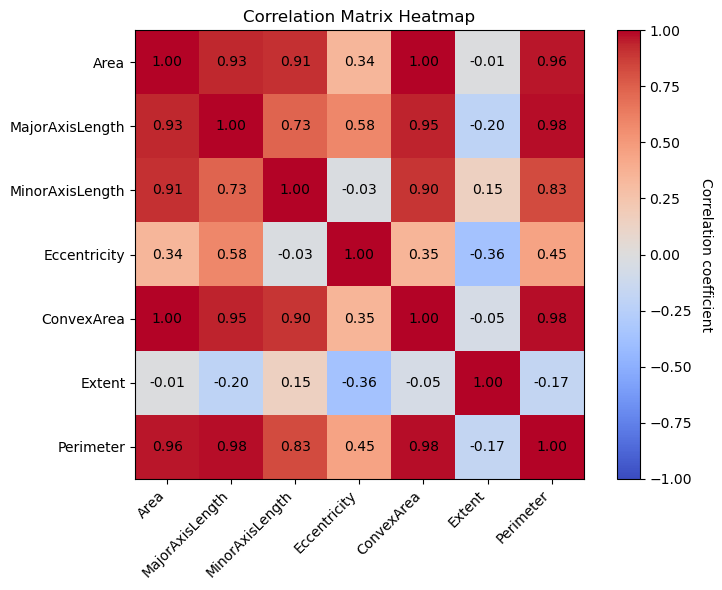

In [242]:
# Compute the correlation matrix
import pandas as pd
import matplotlib.pyplot as plt

correlation_matrix = df.drop(columns=["Class"]).corr()#find the correlation matrix to learn features relation to each other
print(correlation_matrix)
# heatmap
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Correlation coefficient", rotation=270, labelpad=15)


ax.set_xticks(np.arange(len(correlation_matrix.columns)))
ax.set_yticks(np.arange(len(correlation_matrix.columns)))
ax.set_xticklabels(correlation_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(correlation_matrix.columns)
#write every correlation coefficient to the cells(7x7 matrice)
for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        value = correlation_matrix.iloc[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", color="black")

ax.set_title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()

3. Choose two features: Based on the correlation analysis, select two features that are
least correlated (e.g., variance and skewness) to visualize the Perceptron’s decision
boundary.

In [362]:

# Select two features (for example (Area and ConvexArea) and two more pair) according to their correlation
'''(Area and Extent)--->0.01'''
'''(MinorAxisLength and Eccentricity-->0.03'''
'''(ConvexArea and Extent)-->0.05'''
# Select these features from the original feature set
X_selected = df.drop(columns=["Class","MajorAxisLength","MinorAxisLength","Eccentricity"
           ,"ConvexArea","Perimeter"]).to_numpy(dtype=float)
# Find a pair of features such that the separation between classes is at its highest level. Similarly, find a pair of features such that the separation between classes is at its lowest level. Finally, find the pair of features with average separability.
import itertools
import pandas as pd
import numpy as np
import itertools


df = pd.read_csv("Raisin_Dataset.csv")

#numeric convertion of pandas dataframes columns
for col in df.columns:
    if col != 'Class':
        df[col] = pd.to_numeric(df[col], errors='coerce')


# features list 
features = ['Area','MajorAxisLength','MinorAxisLength','Eccentricity',
            'ConvexArea','Extent','Perimeter']


def accuracy_score(f1,f2):
      X_selected = df[[f1,f2]].to_numpy(dtype=float)

       #train and scale data with only selected feature columns then calculate training accuracy
      scaler = StandardScaler()
      X_selected = scaler.fit_transform(X_selected)
      X_train_selected,X_valid,y_train_selected,y_valid=train_test_split(X_selected, y, train_size=0.8, test_size=0.2,random_state=42,stratify=y)
      
      p = Perceptron(learning_rate=0.001, epochs=500,random_state=42)
      p.fit(X_train_selected,y_train_selected)
      y_pred_selected=p.predict(X_train_selected)
      score=np.mean(y_pred_selected == y_train_selected)
      return score

# Compute all possible pairs and their accuracy score via accuracy score function
rows = []
for f1, f2 in itertools.combinations(features, 2):
    score = accuracy_score(f1, f2)
    rows.append({"Feature 1": f1, "Feature 2": f2, "Separability Score": score})

scores_df = pd.DataFrame(rows)
scores_df = scores_df.replace([np.inf, -np.inf], np.nan).dropna()
scores_df = scores_df.sort_values("Separability Score", ascending=False)
#Find highest sepeerability lowest and average
print("=== Highest separability pair ===")
print(scores_df.iloc[0], "\n")

print("=== Lowest separability pair ===")
print(scores_df.iloc[-1], "\n")

print("=== Middle (average) separability pair ===")
print(scores_df.iloc[len(scores_df)//2], "\n")

# Split the selected features into training and validation sets if not done yet
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler() #standardization process before splitting data into train and test


X_selected = scaler.fit_transform(X_selected)
X_train_selected,X_valid,y_train_selected,y_valid=train_test_split(X_selected, y, train_size=0.8, test_size=0.2,random_state=42,stratify=y)
#since i used not scaled df while choosing 2 features i scaled again

=== Highest separability pair ===
Feature 1                  Area
Feature 2             Perimeter
Separability Score       0.8625
Name: 5, dtype: object 

=== Lowest separability pair ===
Feature 1             MinorAxisLength
Feature 2                      Extent
Separability Score           0.576389
Name: 13, dtype: object 

=== Middle (average) separability pair ===
Feature 1             Eccentricity
Feature 2               ConvexArea
Separability Score        0.836111
Name: 15, dtype: object 



#### Step 2: Train the Perceptron on Selected Features (10 points)

1. Retrain the Perceptron: After selecting two features, train the Perceptron using
only these two features. Use the same training and evaluation process as before,
but now the model will work in a two-dimensional feature space.

In [363]:
## Train the Perceptron model on the training set.
p = Perceptron(learning_rate=0.001, epochs=500,random_state=42)
p.fit(X_train_selected,y_train_selected)
y_pred_selected=p.predict(X_train_selected)
accuracy_train_selected=np.mean(y_pred_selected == y_train_selected)
# Predicting on the training data
print("Training Accuracy:", accuracy_train_selected)

Training Accuracy: 0.8291666666666667


In [364]:
#Find testing accuracy
p.fit(X_train_selected,y_train_selected)
y_pred_selected=p.predict(X_valid)
accuracy_train_selected=np.mean(y_pred_selected == y_valid)
# Predicting on the training data
print("Testing Accuracy:", accuracy_train_selected)

Testing Accuracy: 0.8166666666666667


2. Visualize the decision boundary (hyperplane): Once the Perceptron is trained, plot
the decision boundary (hyperplane) to see how the Perceptron separates the two
classes in 2D.

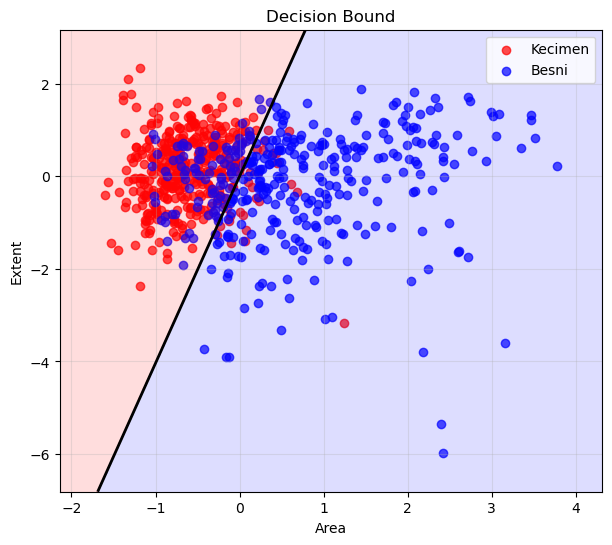

In [201]:
# Function to plot the decision boundary
def plot_decision_boundary(X, y, model):
    plt.figure(figsize=(7, 6))
    plt.scatter(X[y == 1, 0], X[y == 1, 1], color='red', label='Kecimen', alpha=0.7)
    plt.scatter(X[y == -1, 0], X[y == -1, 1], color='blue', label='Besni', alpha=0.7)

    x_min, x_max = X[:, 0].min() - 0.1 * np.ptp(X[:, 0]), X[:, 0].max() + 0.1 * np.ptp(X[:, 0])
    y_min, y_max = X[:, 1].min() - 0.1 * np.ptp(X[:, 1]), X[:, 1].max() + 0.1 * np.ptp(X[:, 1])
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                         np.linspace(y_min, y_max, 400))

    zz = model.weights[0] * xx + model.weights[1] * yy + model.bias
    plt.contourf(xx, yy, np.sign(zz), alpha=0.15, cmap='bwr')
    plt.contour(xx, yy, zz, levels=[0], colors='black', linewidths=2)

    plt.xlabel("Area")
    plt.ylabel("Extent")
    plt.legend()
    plt.title("Decision Bound")
    plt.grid(alpha=0.3)
    plt.show()

# Plot the decision boundary using the selected features and trained model
p.fit(X_train_selected, y_train_selected)
plot_decision_boundary(X_train_selected,y_train_selected,p)

#### Step 3: Experiment with Different Features (10 points)

After visualizing the decision boundary for one pair of features, try selecting different
combinations of features (e.g., Area and MaxorAxisLength) and retrain the Perceptron. Compare
how the hyperplane changes with different features. This helps in understanding how the
Perceptron’s decision-making process adapts to different feature sets.

In [193]:
#For different pair, same process 
X_selected_diff = df.drop(columns=["Area","Class","MajorAxisLength"
           ,"Extent","ConvexArea","Perimeter"]).to_numpy(dtype=float)
X_selected_diff = scaler.fit_transform(X_selected_diff)
X_train_selected_diff,X_valid_diff,y_train_selected_diff,y_valid_diff=train_test_split(X_selected_diff, y, train_size=0.8, test_size=0.2,random_state=42,stratify=y)


In [194]:
p.fit(X_train_selected_diff,y_train_selected_diff)
y_pred_selected_diff=p.predict(X_train_selected_diff)
accuracy_train_selected_diff=np.mean(y_pred_selected_diff == y_train_selected_diff)
# Predicting on the training data
print("Training Accuracy:", accuracy_train_selected_diff)

Training Accuracy: 0.8458333333333333


In [198]:
p.fit(X_train_selected_diff,y_train_selected_diff)
y_pred_selected_diff=p.predict(X_valid_diff)
accuracy_train_selected_diff=np.mean(y_pred_selected_diff == y_valid_diff)
print("Testing Accuracy:", accuracy_train_selected_diff)

Testing Accuracy: 0.8444444444444444


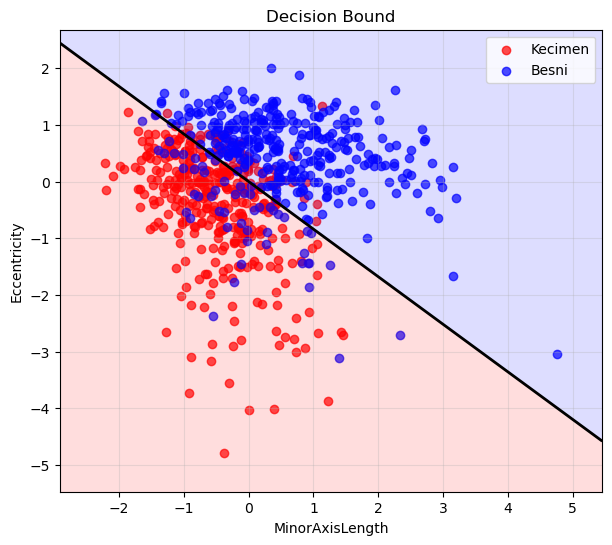

In [195]:
def plot_decision_boundary(X, y, model):
    plt.figure(figsize=(7, 6))
    plt.scatter(X[y == 1, 0], X[y == 1, 1], color='red', label='Kecimen', alpha=0.7)
    plt.scatter(X[y == -1, 0], X[y == -1, 1], color='blue', label='Besni', alpha=0.7)

    x_min, x_max = X[:, 0].min() - 0.1 * np.ptp(X[:, 0]), X[:, 0].max() + 0.1 * np.ptp(X[:, 0])
    y_min, y_max = X[:, 1].min() - 0.1 * np.ptp(X[:, 1]), X[:, 1].max() + 0.1 * np.ptp(X[:, 1])
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                         np.linspace(y_min, y_max, 400))

    zz = model.weights[0] * xx + model.weights[1] * yy + model.bias
    plt.contourf(xx, yy, np.sign(zz), alpha=0.15, cmap='bwr')
    plt.contour(xx, yy, zz, levels=[0], colors='black', linewidths=2)

    plt.xlabel("MinorAxisLength")
    plt.ylabel("Eccentricity")
    plt.legend()
    plt.title("Decision Bound")
    plt.grid(alpha=0.3)
    plt.show()

# Plot the decision boundary using the selected features and trained model
p.fit(X_train_selected_diff, y_train_selected_diff)
plot_decision_boundary(X_train_selected_diff,y_train_selected_diff,p)

* Answer the guiding questions:  
1. How does the decision boundary change when you use different pairs of features?  
2. Can you find a pair of features that leads to better separation between the two classes? Also explain why this feature pair causes the better separation.  
3. If the classes cannot be linearly separated in a given pair of features, can we still talk about a linear relationship between them? Explain your reasoning.


In [ ]:
'''1) 
First plot (Area vs. Extent)
The decision boundary is flatter and the red and blue samples overlap more heavily near the middle.
The classifier still separates them but less cleanly — you can see many red points inside the blue region and vice versa.


Second plot (Eccentricity vs. MinorAxisLength)
The decision boundary is steep and clear, roughly diagonal, and it separates most red (Kecimen) and blue (Besni) samples quite well.
The overlap region is small, and the classes are distributed in opposite sides of the boundary.



2)After computing the Perceptron accuracy for all possible feature pairs, 
the pair Area–Perimeter achieved the highest separability (0.86), 
while MinorAxisLength–Extent had the lowest (0.57). 
Although correlation analysis suggested that less correlated pairs might provide better separation
(due to high overlap possibility),our results show that this is not always the case. 
Highly correlated features (like Area and Perimeter) can still yield excellent classification results 
if both vary consistently between classes. 
Therefore, correlation measures feature redundancy, 
not their ability to discriminate between classes. 
The best feature pair is the one whose values are most distinct for different classes, 
even if the features themselves are correlated.



3)If classes cannot be linearly separated in a given feature pair, 
we can’t claim a strong linear relationship. 
The data might still show a non-linear pattern, but a linear model like the perceptron cannot capture it effectively.


#### Bonus Step 4: Incrementally Add Data (+ 5 points)

1. Visualizing Incremental Learning: Another experiment to help understand the behavior of the Perceptron is to add data incrementally. Start with a small portion of the dataset and progressively add more data points to train the Perceptron.

* For example, draw the decision boundary using the first 5% of the data, then increase it by 10% increments, continuing the process until the entire dataset is used, and draw the decision boundary at each step.


In [314]:
X_all = df[["Area","Extent"]].to_numpy(dtype=float)
y_all = y.copy().ravel()  


scaler = StandardScaler()
X_all = scaler.fit_transform(X_all)

#Shuffle data set for more homogenous choose of data in minor data sets
rng = np.random.RandomState(42)
indices = np.arange(len(X_all))
rng.shuffle(indices)
X_all = X_all[indices]
y_all = y_all[indices]

X_train_data,X_valid_data,y_train_data,y_valid_data=train_test_split(X_all, y_all, train_size=0.8, test_size=0.2,random_state=42,stratify=y)




def plot_boundary(X, y, model, title):
    plt.figure(figsize=(6, 5))
    plt.scatter(X[y == 1, 0], X[y == 1, 1], color='green', label='Kecimen', alpha=0.7)
    plt.scatter(X[y == -1, 0], X[y == -1, 1], color='blue', label='Besni', alpha=0.7)

    x_min, x_max = X[:, 0].min() - 0.1*np.ptp(X[:,0]), X[:, 0].max() + 0.1*np.ptp(X[:,0])
    y_min, y_max = X[:, 1].min() - 0.1*np.ptp(X[:,1]), X[:, 1].max() + 0.1*np.ptp(X[:,1])
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.15, cmap='bwr')
    plt.contour(xx, yy, Z, levels=[0], colors='black', linewidths=2)

    plt.title(title)
    plt.xlabel("Extent")
    plt.ylabel("Area")
    plt.legend()
    plt.show()


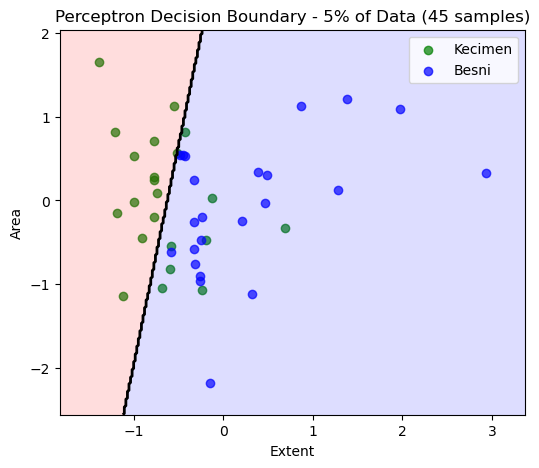

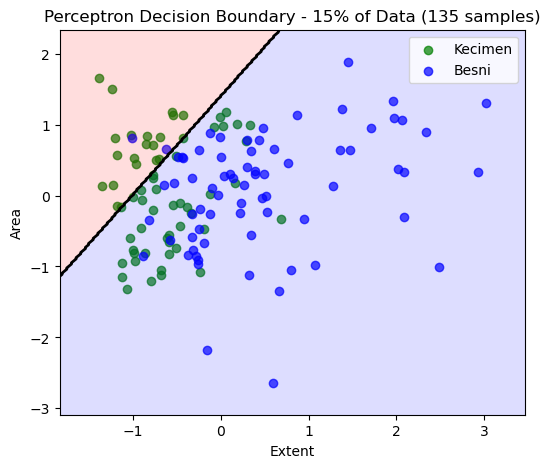

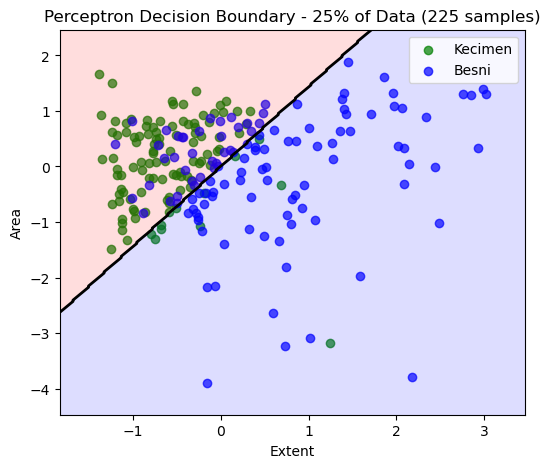

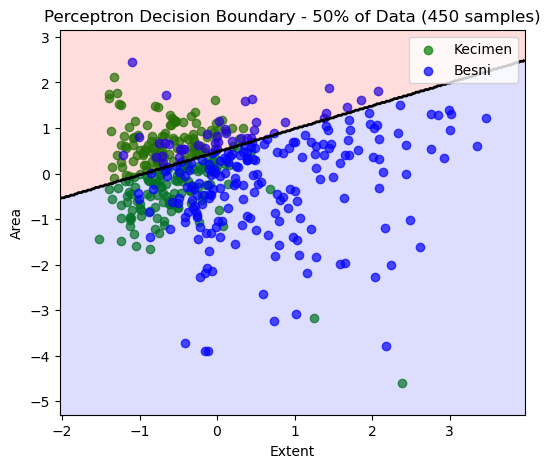

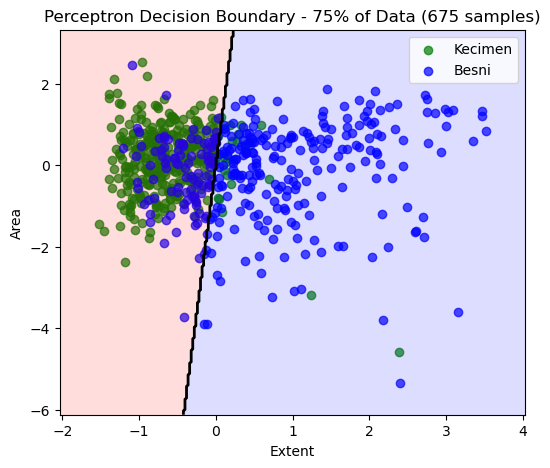

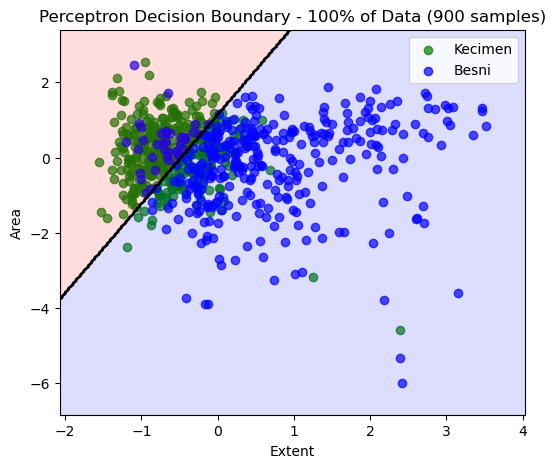

In [315]:
#add data incrementally in chosen 2 feature plane which are Extent and Area
percentages = [5, 15, 25, 50, 75, 100]
for p in percentages:
    n_samples = int(len(X) * p / 100)
    X_subset, y_subset = X_train_data[:n_samples], y_train_data[:n_samples]


    perceptron = Perceptron(learning_rate=0.001, epochs=1000, random_state=42)
    perceptron.fit(X_subset, y_subset)

    plot_boundary(X_subset, y_subset, perceptron,
                  title=f"Perceptron Decision Boundary - {p}% of Data ({n_samples} samples)")

2. Observe how the decision boundary shifts: As you add more data, observe how the
hyperplane shifts and adapts to new points. This will help you understand how the
Perceptron continuously adjusts the boundary to separate the classes.

In [ ]:
'''We selected two features again for showing clearly in the graph
and its the same features that are least correlated pair in the heatmap
EXTENT and AREA. As we add more data to our space, the Perceptron algorithm started to seperate
classes more accurately because it trained better with more datas,learned better and found better weights
for our hyperplane'''

#### Step 6: Fisher’s Linear Discriminant Projection (10 points)
* In this step, you will implement Fisher’s Linear Discriminant (LD) to project the
dataset onto a 1D space and visualize the distribution of the two classes in the projected
space using a histogram. The goal of Fisher’s LD is to find the direction in the feature
space that maximizes the separation between two classes while minimizing the variance
within each class. This technique projects the data onto a single dimension where the
separation between the classes is optimized.

In [328]:
def fisher_ld_projection(X, y):
    """Compute Fisher's Linear Discriminant projection direction."""
    X1 = X[y == 1]   # Kecimen
    X2 = X[y == -1]  # Besni

    m1 = np.mean(X1, axis=0)
    m2 = np.mean(X2, axis=0)


    S1 = np.cov(X1, rowvar=False)
    S2 = np.cov(X2, rowvar=False)
    SW = S1 + S2

    # direction vector
    w = np.linalg.inv(SW).dot(m1 - m2)
    return w

#project to all data 
def project_data(X,direction):
    """Project data onto the Fisher LD direction."""
    direction = direction / np.linalg.norm(direction)  #normalization
    projections = X.dot(direction)
    return projections


In [329]:
direction = fisher_ld_projection(X,y)
# Project the data onto the Fisher LD direction
projected_data = project_data(X,direction)

### Visualizations
#### 2D Feature Space (Optional but Recommended)
* While not mandatory, it can be highly instructive to visualize the projection direction computed by Fisher’s LD in the original 2D feature space. This will help you understand how the data is being projected onto a 1D space and why this direction is optimal for class separation.

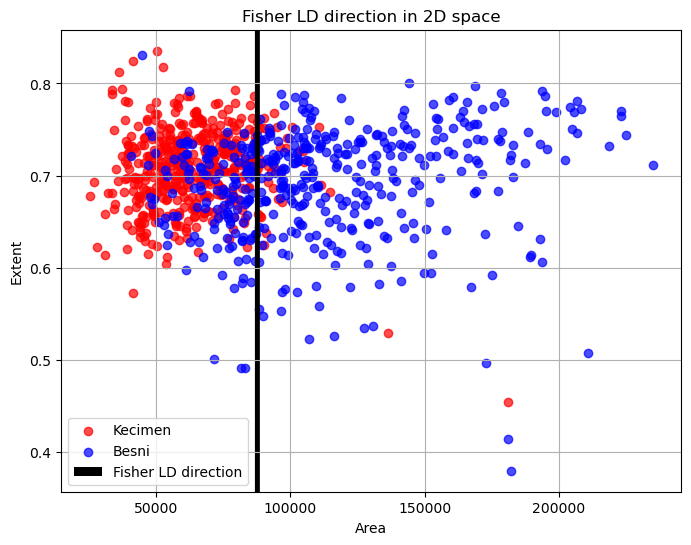

In [360]:

# Plot the 2D data with the projection direction
features = ['Area', 'Extent']
X_2D = df[features].to_numpy(dtype=float)
direction_2D=fisher_ld_projection(X_2D,y)
projected_data_2D=project_data(X_2D,direction_2D)# 2) class means and midpoint
mean1 = np.mean(X_2D[y == 1], axis=0)
mean2 = np.mean(X_2D[y == -1], axis=0)
midpoint = (mean1 + mean2) / 2


range_x = np.ptp(X_2D[:, 0])
range_y = np.ptp(X_2D[:, 1])

scale_factor = 0.5 * np.sqrt(range_x**2 + range_y**2)
arrow = w * scale_factor

plt.figure(figsize=(8, 6))
plt.scatter(X_2D[y == 1, 0], X_2D[y == 1, 1], c="red", alpha=0.7, label="Kecimen")
plt.scatter(X_2D[y == -1, 0], X_2D[y == -1, 1], c="blue", alpha=0.7, label="Besni")


plt.quiver(
    midpoint[0], midpoint[1],
    arrow[0], arrow[1],
    angles="xy", scale_units="xy", scale=1,
    color="black", width=0.008, headwidth=10, headlength=12,
    label="Fisher LD direction"
)


plt.quiver(
    midpoint[0], midpoint[1],
    -arrow[0], -arrow[1],
    angles="xy", scale_units="xy", scale=1,
    color="black", width=0.008, headwidth=10, headlength=12
)

plt.xlabel(features[0])
plt.ylabel(features[1])
plt.title("Fisher LD direction in 2D space")
plt.legend()
plt.grid(True)
plt.show()


# Hint: You can use plt.scatter() to plot the 2D data with its features
# You can find the mean of the entire dataset for placing the direction vector
# Hint: You can use plt.quiver() method to visualize the direction vector
# Do not forget to scale the direction vector to visualize it properly
# Adjust this to control the length of the direction line

### 1D Projected Space (Required)
* Plot a histogram showing the distribution of the
projected data for each class in the 1D space. The histogram will help you visualize
how well the two classes are separated by the Fisher’s LD projection.

In [ ]:
# Plot the histogram of the projected data

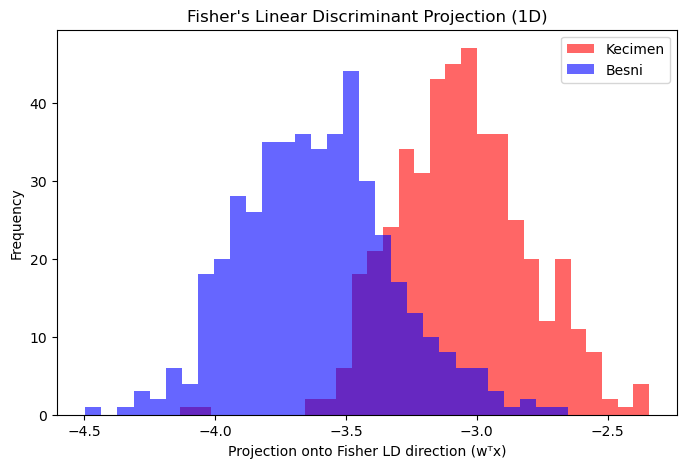

In [361]:

def plot_histogram(X,direction,projections):
 plt.figure(figsize=(8,5))
 plt.hist(projections[y == 1], bins=30, alpha=0.6, color='red', label='Kecimen')
 plt.hist(projections[y == -1], bins=30, alpha=0.6, color='blue', label='Besni')
 plt.xlabel("Projection onto Fisher LD direction (wᵀx)")
 plt.ylabel("Frequency")
 plt.title("Fisher's Linear Discriminant Projection (1D)")
 plt.legend()
 plt.show()

plot_histogram(X,direction,projected_data)

Answer the guiding questions:
1. How well does Fisher’s LD separate the two classes in the 1D projected space?
2. Compare the separation of the two classes in the original 2D space (used in the
Perceptron) versus the 1D Fisher’s LD projection. What do you observe about the
class distributions in these spaces?

'''Fisher’s Linear Discriminant projects the multi-feature data onto a single dimension that maximizes the separation between the two raisin classes.
In the original 2D feature space used for the Perceptron, the classes were linearly separable but with moderate overlap near the boundary.
However, in the 1D Fisher projection, the distributions of Kecimen and Besni are more compact and located farther apart.
This indicates that Fisher’s LD effectively captured the optimal discriminating direction between the two classes, resulting in better class separation in the projected space than in the manually chosen 2D feature pair.'''